In [1]:
import os
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler
from category_encoders import CountEncoder
from sklearn.base import clone
from sklearn.decomposition import PCA

In [2]:
from plot_utils import pca_2d_feature_plot

In [3]:
current_dir = os.getcwd()

In [4]:
flights_sampled_parquet = "flights_sampled.parquet"

try:
    df_flights_sampled = pd.read_parquet(os.path.join(current_dir, flights_sampled_parquet))
except FileNotFoundError:
    print(f"Arquivo {flights_sampled_parquet} não encontrado. Certifique-se de rodar o notebook 'us_flights_ml_eda_sampled.ipynb'.")
    raise

In [5]:
df_flights_sampled.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   DESTINATION_STATE        100000 non-null  category
 1   ORIGIN_STATE             100000 non-null  category
 2   MONTH                    100000 non-null  category
 3   DAY                      100000 non-null  category
 4   DAY_OF_WEEK              100000 non-null  category
 5   AIRLINE                  100000 non-null  category
 6   FLIGHT_SEQUENCE          100000 non-null  int64   
 7   ORIGIN_AIRPORT           100000 non-null  category
 8   DESTINATION_AIRPORT      100000 non-null  category
 9   DISTANCE                 100000 non-null  int64   
 10  SCHEDULED_TIME           100000 non-null  int64   
 11  ARRIVAL_DELAY            100000 non-null  int64   
 12  HOUR                     100000 non-null  category
 13  ROUTE                    100000 non-null  category
 14  

In [6]:
df_flights_sampled.dropna(inplace=True)

## Encoding / Scaling

In [7]:
# Colunas categóricas não ordenadas de baixa cardinalidade (One-Hot Encoding)
ohe_cat_cols = ["AIRLINE"]

# Colunas categóricas não ordenadas de alta cardinalidade (Frequency Encoding)
freq_cat_cols = [
    "ORIGIN_AIRPORT", "ORIGIN_CITY", "ORIGIN_STATE",
    "DESTINATION_AIRPORT", "DESTINATION_CITY", "DESTINATION_STATE",
    "ROUTE",
]

# Colunas categóricas ordenadas (Ordinal Encoding + MinMax Scaler)
oe_cat_cols = ["DISTANCE_CATEGORY", "SCHEDULED_TIME_CATEGORY"]

dist_cat_labels = [
    "Short Distance",
    "Medium Distance",
    "Long Distance",
]

sch_time_cat_labels = [
    "Short Duration",
    "Medium Duration",
    "Long Duration",
    "Very Long Duration",
]

# Colunas categóricas ordenadas (MinMax Scaler)
sc_cat_cols = ["MONTH", "DAY", "DAY_OF_WEEK", "HOUR", "FLIGHT_SEQUENCE"]

# Colunas numéricas (MinMax Scaler)
minmax_num_cols = ["DISTANCE", "SCHEDULED_TIME", "DEPARTURE_ACC_MINUTES", "ARRIVAL_ACC_MINUTES"]

# Colunas numéricas (Standard Scaler)
std_num_cols = ["ORIGIN_LATITUDE", "ORIGIN_LONGITUDE", "DESTINATION_LATITUDE", "DESTINATION_LONGITUDE"]

# Colunas booleanas (Passthrough)
bool_cols = ["HOLIDAY_ORIGIN", "HOLIDAY_EVE_ORIGIN", "HOLIDAY_DESTINATION", "HOLIDAY_EVE_DESTINATION"]

preprocessor_standard = ColumnTransformer(
    transformers=[
        ("ohe", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False), ohe_cat_cols),
        ("freq", CountEncoder(handle_unknown="value", normalize=True), freq_cat_cols),
        ("ord", Pipeline([
            ("enc", OrdinalEncoder(handle_unknown="error", categories=[dist_cat_labels, sch_time_cat_labels])),
            ("scaler", MinMaxScaler()),
        ]), oe_cat_cols),
        ("ord_minmax_scaler", MinMaxScaler(), sc_cat_cols),
        ("minmax_scaler", MinMaxScaler(), minmax_num_cols),
        ("std_scaler", StandardScaler(), std_num_cols),
    ],
    remainder="passthrough"
)

## PCA

In [8]:
X = df_flights_sampled.drop(columns=["ARRIVAL_DELAY"])

In [9]:
preprocessor_pca = clone(preprocessor_standard)
X_pca = preprocessor_pca.fit_transform(X)

In [10]:
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_pca)

df_pca_2d = pd.DataFrame(X_pca_2d, columns=["PC1", "PC2"])

In [11]:
print(f"PC1 explained variance: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2 explained variance: {pca.explained_variance_ratio_[1]:.2%}")

PC1 explained variance: 29.23%
PC2 explained variance: 23.39%


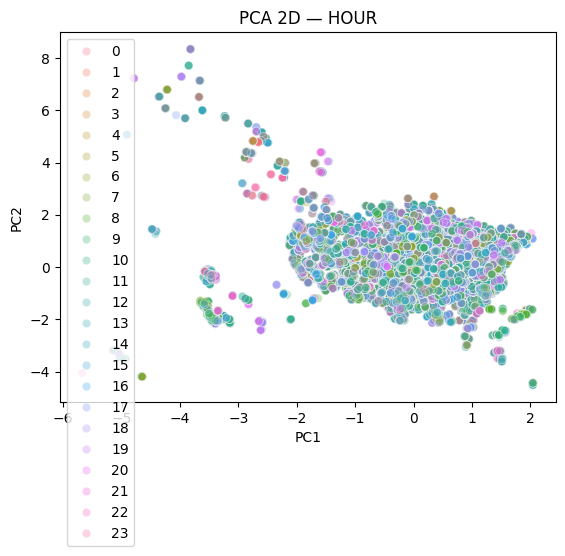

In [12]:
pca_2d_feature_plot(df_pca_2d, df_flights_sampled["HOUR"])

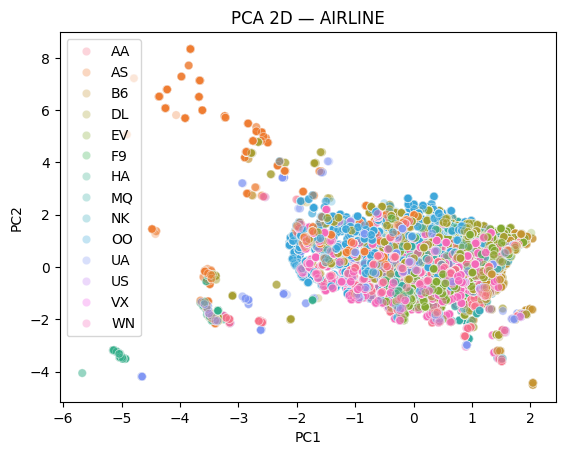

In [13]:
pca_2d_feature_plot(df_pca_2d, df_flights_sampled["AIRLINE"])

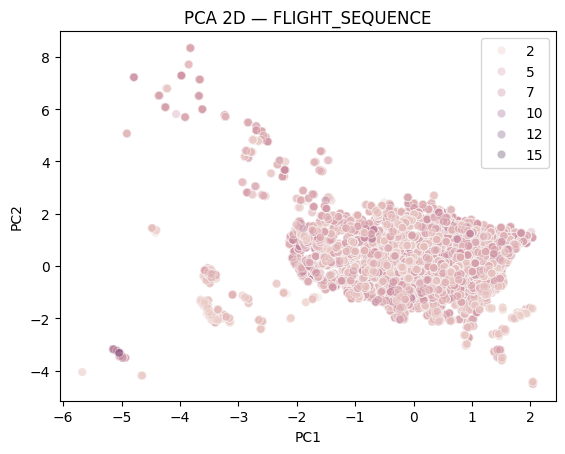

In [14]:
pca_2d_feature_plot(df_pca_2d, df_flights_sampled["FLIGHT_SEQUENCE"])

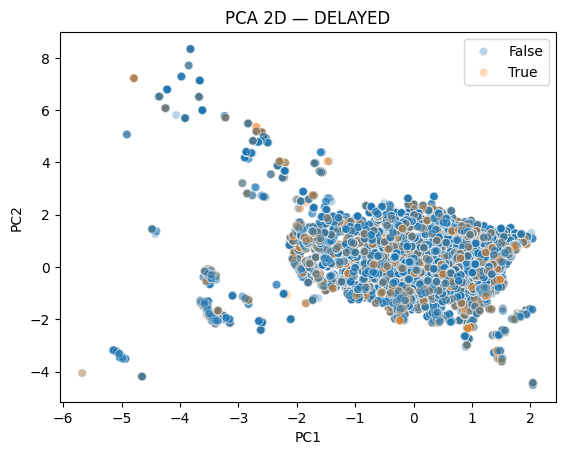

In [15]:
pca_2d_feature_plot(df_pca_2d, (df_flights_sampled["ARRIVAL_DELAY"] >= 15).rename("DELAYED"))